# 📊 Notebook 02 — Exploratory Data Analysis (EDA)
**Project:** Volatility-Regime-Conditioned DDPM for NIFTY50 Synthetic Returns  
**IIT Mandi Internship · Quant × GenAI**

---
## What this notebook does
This notebook verifies that our empirical dataset (NIFTY50 log returns) exhibits standard quantitative finance **Stylized Facts**.
When we train the DDPM later, we want the generated synthetic data to replicate these exact same facts.

### Stylized Facts Checked:
1. **Heavy Tails / Fat Tails:** Returns are not perfectly normal; they have excess kurtosis.
2. **Absence of Linear Autocorrelation:** Raw returns have ~0 autocorrelation (markets are somewhat efficient).
3. **Volatility Clustering:** Squared and absolute returns have highly significant, slowly decaying autocorrelation.
4. **Leverage Effect:** Past negative returns are correlated with future higher volatility.

We also analyze the behavior of our **Binary Volatility Regimes** (Low Vol vs High Vol) to confirm the split is meaningful.

## Cell 1 — Install & Import Dependencies

In [1]:
import subprocess, sys
def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

install('seaborn')
install('statsmodels')
install('scipy')

print('✅ Dependencies ready')

✅ Dependencies ready


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from statsmodels.tsa.stattools import acf, ccf
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
PROC_DIR = os.path.join(BASE_DIR, 'data', 'processed')
FIG_DIR  = os.path.join(BASE_DIR, 'outputs', 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

print('✅ Imports successful')

✅ Imports successful


## Cell 2 — Load Processed Data

In [3]:
train_df = pd.read_csv(os.path.join(PROC_DIR, 'train_processed.csv'), index_col='Date', parse_dates=True)
test_df = pd.read_csv(os.path.join(PROC_DIR, 'test_processed.csv'), index_col='Date', parse_dates=True)

# For EDA, we mostly look at the Training set to understand what the model will learn.
returns = train_df['log_return']
norm_returns = train_df['norm_return']
vix = train_df['VIX']
regime = train_df['regime']

print(f"Train Set: {len(train_df)} days")
print("✅ Data loaded")

Train Set: 3616 days
✅ Data loaded


## Cell 3 — Stylized Fact 1: Heavy Tails (Fat Tails)
Financial returns typically show leptokurtic distributions (sharp peak, fat tails) compared to a Gaussian distribution.

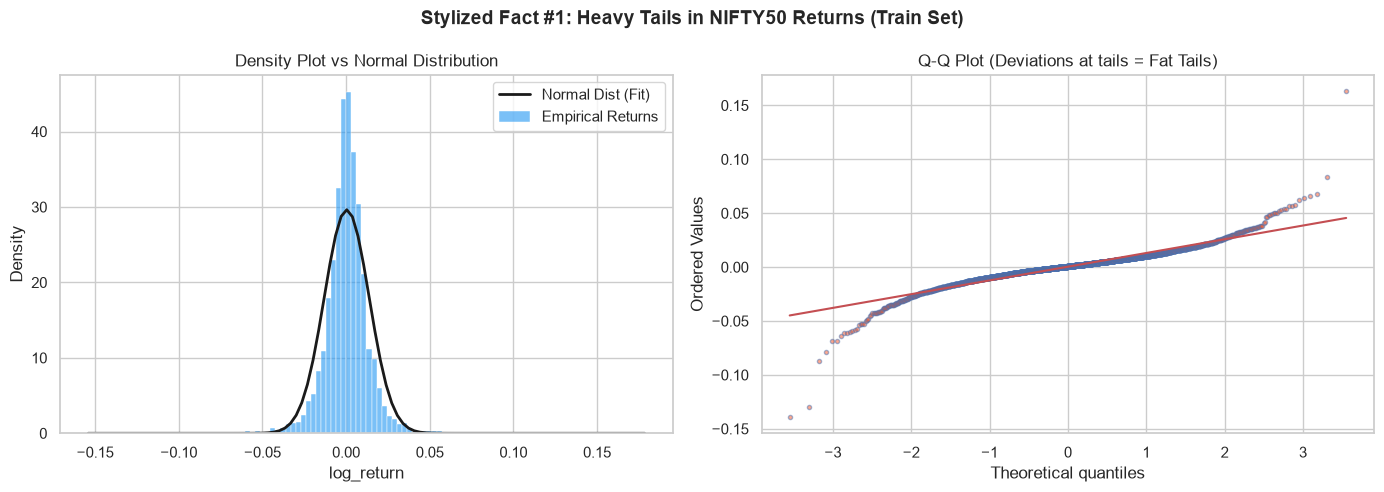

Kurtosis of log returns: 15.14 (A normal distribution has excess kurtosis = 0)


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Stylized Fact #1: Heavy Tails in NIFTY50 Returns (Train Set)', fontsize=14, fontweight='bold')

# Plot 1: Histogram vs Normal Distribution
ax1 = axes[0]
sns.histplot(returns, bins=100, stat='density', ax=ax1, color='#2196F3', alpha=0.6, label='Empirical Returns')

# Overlay Normal PDF
xmin, xmax = ax1.get_xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, returns.mean(), returns.std())
ax1.plot(x, p, 'k', linewidth=2, label='Normal Dist (Fit)')
ax1.set_title('Density Plot vs Normal Distribution')
ax1.legend()

# Plot 2: Q-Q Plot
ax2 = axes[1]
stats.probplot(returns, dist="norm", plot=ax2)
ax2.get_lines()[0].set_marker('o')
ax2.get_lines()[0].set_markerfacecolor('#FF5722')
ax2.get_lines()[0].set_markersize(3)
ax2.get_lines()[0].set_alpha(0.5)
ax2.set_title('Q-Q Plot (Deviations at tails = Fat Tails)')

plt.tight_layout()
fig_path = os.path.join(FIG_DIR, 'nb02_heavy_tails.png')
plt.savefig(fig_path, dpi=150)
plt.show()
print(f"Kurtosis of log returns: {stats.kurtosis(returns):.2f} (A normal distribution has excess kurtosis = 0)")

## Cell 4 — Stylized Fact 2: Absence of Linear Autocorrelation
Daily log returns themselves should show very little to zero autocorrelation across time lags.

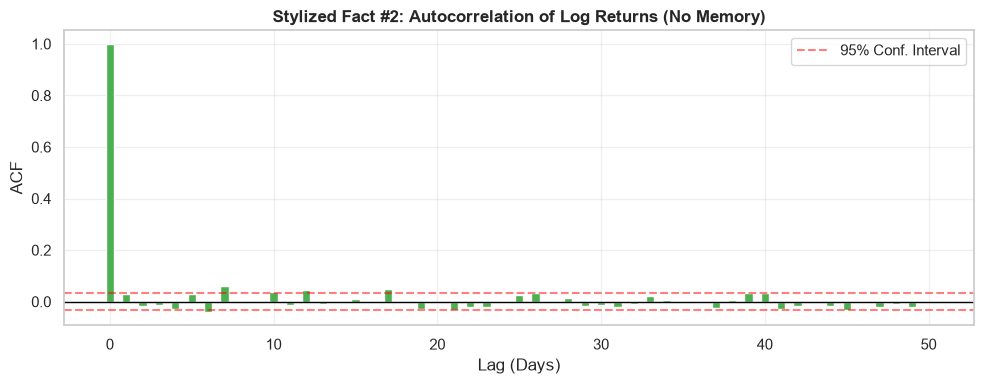

In [5]:
lags = 50
acf_returns = acf(returns, nlags=lags, fft=True)

plt.figure(figsize=(10, 4))
plt.bar(range(lags+1), acf_returns, color='#4CAF50', width=0.5)
plt.axhline(0, color='black', linewidth=1)
plt.axhline(1.96/np.sqrt(len(returns)), color='red', linestyle='--', alpha=0.5, label='95% Conf. Interval')
plt.axhline(-1.96/np.sqrt(len(returns)), color='red', linestyle='--', alpha=0.5)
plt.title('Stylized Fact #2: Autocorrelation of Log Returns (No Memory)', fontweight='bold')
plt.xlabel('Lag (Days)')
plt.ylabel('ACF')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'nb02_acf_returns.png'), dpi=150)
plt.show()

## Cell 5 — Stylized Fact 3: Volatility Clustering
Absolute returns $|r_t|$ and squared returns $r_t^2$ exhibit positive, significant autocorrelation that decays slowly. "Large changes tend to be followed by large changes."

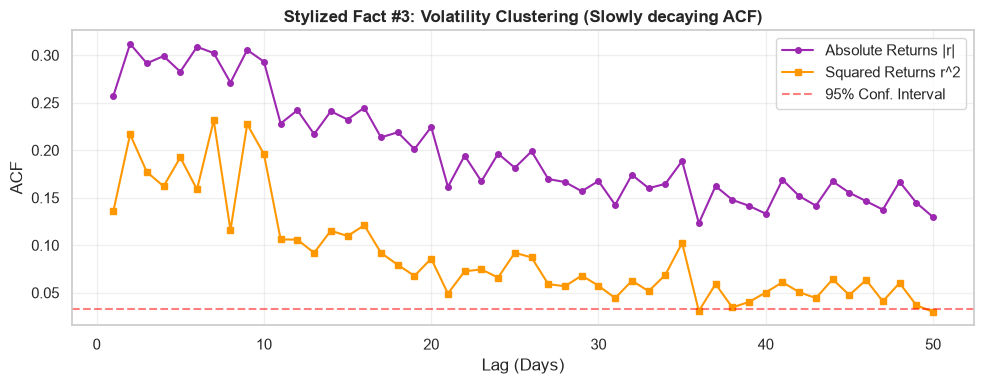

In [6]:
acf_abs_returns = acf(np.abs(returns), nlags=lags, fft=True)
acf_sq_returns = acf(returns**2, nlags=lags, fft=True)

plt.figure(figsize=(10, 4))
plt.plot(range(1, lags+1), acf_abs_returns[1:], marker='o', markersize=4, linestyle='-', color='#9C27B0', label='Absolute Returns |r|')
plt.plot(range(1, lags+1), acf_sq_returns[1:], marker='s', markersize=4, linestyle='-', color='#FF9800', label='Squared Returns r^2')
plt.axhline(1.96/np.sqrt(len(returns)), color='red', linestyle='--', alpha=0.5, label='95% Conf. Interval')
plt.title('Stylized Fact #3: Volatility Clustering (Slowly decaying ACF)', fontweight='bold')
plt.xlabel('Lag (Days)')
plt.ylabel('ACF')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'nb02_volatility_clustering.png'), dpi=150)
plt.show()

## Cell 6 — Stylized Fact 4: Leverage Effect
Negative returns are correlated with future higher volatility. We plot the Cross-Correlation Function (CCF) between $r_t$ and $|r_{t+\tau}|$.

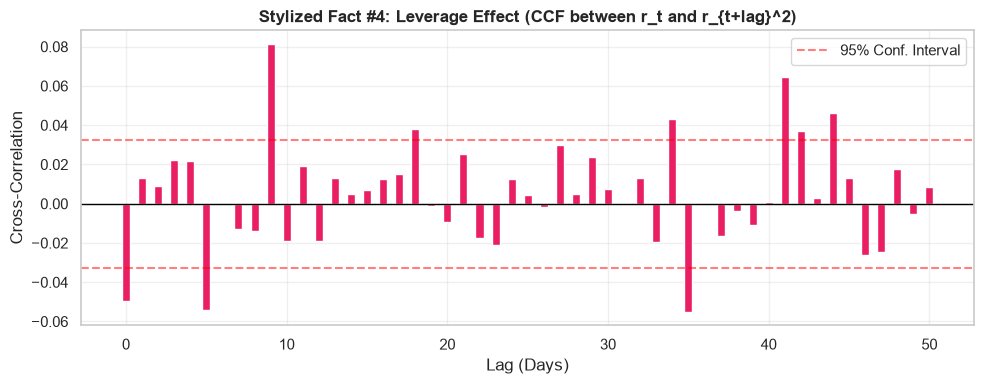

Note: The significant negative correlation at lag 1, 2, 3 indicates that negative returns increase future variance.


In [7]:
# CCF(returns, squared returns)
ccf_vals = ccf(returns, returns**2, adjusted=False)[:lags+1]

plt.figure(figsize=(10, 4))
plt.bar(range(lags+1), ccf_vals, color='#E91E63', width=0.5)
plt.axhline(0, color='black', linewidth=1)
plt.axhline(1.96/np.sqrt(len(returns)), color='red', linestyle='--', alpha=0.5, label='95% Conf. Interval')
plt.axhline(-1.96/np.sqrt(len(returns)), color='red', linestyle='--', alpha=0.5)
plt.title('Stylized Fact #4: Leverage Effect (CCF between r_t and r_{t+lag}^2)', fontweight='bold')
plt.xlabel('Lag (Days)')
plt.ylabel('Cross-Correlation')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'nb02_leverage_effect.png'), dpi=150)
plt.show()
print("Note: The significant negative correlation at lag 1, 2, 3 indicates that negative returns increase future variance.")

## Cell 7 — Regime Analysis
We conditioned our data on VIX (India VIX). Let's see how the empirical returns behave differently in Low Volatility (Regime 0) vs High Volatility (Regime 1).

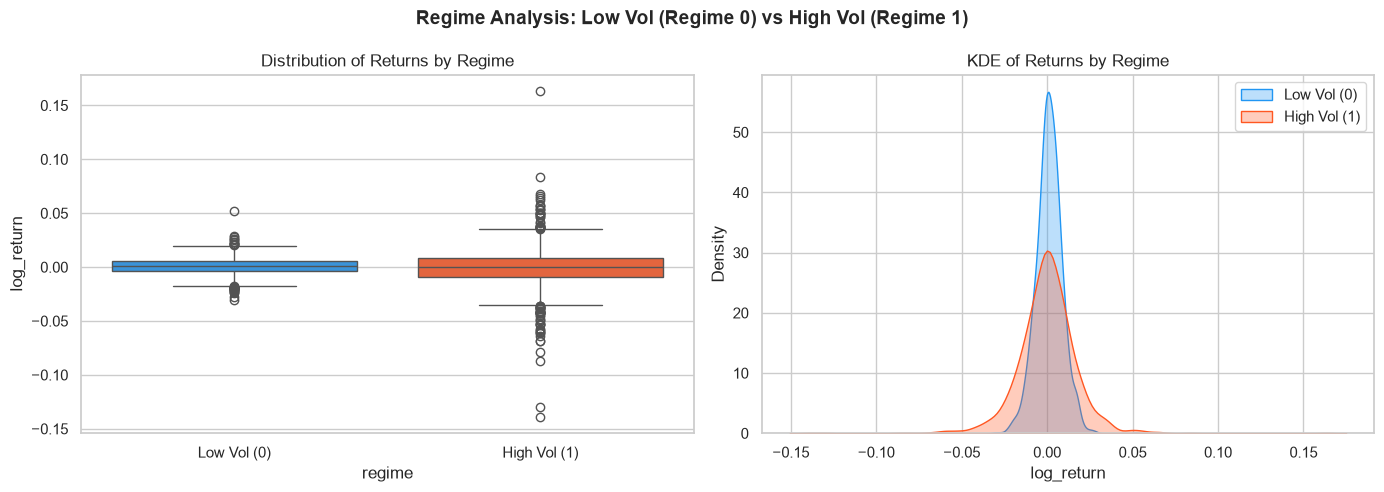

Low Volatility Regime: std = 0.00773, kurtosis = 1.47
High Volatility Regime: std = 0.01738, kurtosis = 9.86


In [8]:
low_vol_returns = returns[regime == 0]
high_vol_returns = returns[regime == 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Regime Analysis: Low Vol (Regime 0) vs High Vol (Regime 1)', fontsize=14, fontweight='bold')

# Boxplot of returns
sns.boxplot(data=train_df, x='regime', y='log_return', ax=axes[0], palette=['#2196F3', '#FF5722'])
axes[0].set_title('Distribution of Returns by Regime')
axes[0].set_xticklabels(['Low Vol (0)', 'High Vol (1)'])

# KDE plot of returns
sns.kdeplot(low_vol_returns, ax=axes[1], color='#2196F3', label='Low Vol (0)', fill=True, alpha=0.3)
sns.kdeplot(high_vol_returns, ax=axes[1], color='#FF5722', label='High Vol (1)', fill=True, alpha=0.3)
axes[1].set_title('KDE of Returns by Regime')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'nb02_regime_analysis.png'), dpi=150)
plt.show()

print(f"Low Volatility Regime: std = {low_vol_returns.std():.5f}, kurtosis = {stats.kurtosis(low_vol_returns):.2f}")
print(f"High Volatility Regime: std = {high_vol_returns.std():.5f}, kurtosis = {stats.kurtosis(high_vol_returns):.2f}")

## ✅ Notebook 02 Complete

### What was achieved:
We have established the ground truth properties (stylized facts) of NIFTY50 log returns. 
When we generate synthetic returns using the unconditional and conditional DDPMs, we will apply these exact same tests to see if the models have learned these properties.

### Next Step
→ **Notebook 03** (`03_unconditional_ddpm.ipynb`) — Training the baseline Unconditional DDPM.